# Point-cloud representations and persistent analysis

This reproducible tutorial samples two overlapping circles of different radii, adds fixed-seed random movement, and introduces four TopoKit representations in this order:

1. **Graph Representation**,
2. **Simplicial Complex Representation**,
3. **Hyperdigraph Representation**, and
4. **Interaction Complex Representation**.

Each stationary representation is plotted and analyzed before a separate persistent-analysis section follows the same order. Homology is computed over GF(2). Laplacian summaries report the complete real spectrum's minimum, maximum, mean, numerical zero count, and energy $E_L=\sum_i |\lambda_i|$.

In [1]:
%matplotlib inline
from itertools import combinations
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
import pandas as pd
from IPython.display import Image as IPythonImage, display

# Restrained Nature-style typography and export settings.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'axes.linewidth': 0.65,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'legend.fontsize': 7,
    'legend.frameon': False,
    'legend.handlelength': 1.8,
    'legend.borderaxespad': 0.25,
    'legend.labelspacing': 0.3,
    'figure.titlesize': 11,
    'figure.titleweight': 'semibold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
    'savefig.facecolor': 'white',
    'savefig.transparent': False,
    'lines.linewidth': 1.1,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'topokit').is_dir() and (candidate / 'pyproject.toml').is_file():
            return candidate
    raise RuntimeError('Run this notebook from the TopoKit project or install TopoKit first.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / 'src'
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from topokit import PointCloud, __version__, core, postprocessing, workflows
from topokit.builders import simplicial, hyperdigraph, interaction
from topokit import visualization as viz

OUTPUT_DIR = PROJECT_ROOT / 'examples' / 'output' / 'point_cloud_topology_workflow'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 20260907
N_LARGE = 20
N_SMALL = 14
N_POINTS = N_LARGE + N_SMALL
SUBSET_SIZE = N_SMALL
LARGE_CENTER = (-0.775, 0.00)
SMALL_CENTER = (0.5, 0.03)
LARGE_RADIUS = 1.00
SMALL_RADIUS = 0.70
SMALL_PHASE = 0.32
ANGULAR_JITTER_SD = 0.08
RADIAL_JITTER_SD = 0.15
CARTESIAN_JITTER_SD = 0.02

EPSILON = 0.55                 # stationary inclusive distance cutoff
ALPHA_RADIUS = EPSILON / 2.0   # stationary proximity-ball radius
PERSISTENT_ALPHA_MAX = 0.80
PERSISTENT_ALPHA_VALUES = np.linspace(0.0, PERSISTENT_ALPHA_MAX, 25)
GIF_ALPHA_VALUES = np.linspace(0.0, PERSISTENT_ALPHA_MAX, 13)
TOL = 1e-10

# The package preset holds the reusable stationary palette and object styling.
STATIONARY_STYLE = viz.StationaryStyle()
PALETTE = STATIONARY_STYLE.palette

print(
    f'TopoKit {__version__}; stationary cutoff ε={EPSILON:.2f}; '
    f'α=ε/2={ALPHA_RADIUS:.3f}; persistent α∈[0,{PERSISTENT_ALPHA_MAX:.2f}]; seed={SEED}'
)


TopoKit 0.3.0; stationary cutoff ε=0.55; α=ε/2=0.275; persistent α∈[0,0.80]; seed=20260907


## Stationary-analysis convention

The stationary examples use one distance cutoff, $\varepsilon=0.55$. Two points are adjacent when their Euclidean distance is at most $\varepsilon$. The corresponding proximity-ball radius is $\alpha=\varepsilon/2=0.275$.

The graph figure displays only points and undirected edges; it does not show proximity circles. The later stationary figures retain faint $\alpha$-circles to connect the higher-order objects to the same geometric cutoff. Point weights do not change the graph or simplicial complex. They determine direction in the hyperdigraph.

The visual encoding is consistent across panels: charcoal marks points, deep blue marks graph edges and $H_0$, green fills 2-simplices, orange marks directed 2-hyperedge segments and $H_1$, and dashed green marks mean spectral values. Direction, line style, filled area, and labels reinforce color so that hue alone never defines the mathematical object. Styling does not change coordinates, cells, directions, filtration values, or numerical analysis.

In [2]:
def publish_figure(fig, stem):
    """Export editable SVG plus a 300-dpi PNG, display, and close."""
    viz.save_figure(fig, OUTPUT_DIR / f'{stem}.svg')
    viz.save_figure(fig, OUTPUT_DIR / f'{stem}.png', dpi=300)
    display(fig)
    plt.close(fig)


def publish_gif(fig, update, frame_values, stem, fps=2):
    """Render a deterministic GIF and display it in the notebook."""
    fig.set_facecolor('white')
    animation = FuncAnimation(
        fig, update, frames=tuple(map(float, frame_values)),
        interval=1000 / fps, repeat=True, blit=False,
    )
    destination = OUTPUT_DIR / f'{stem}.gif'
    animation.save(destination, writer=PillowWriter(fps=fps), dpi=110)
    plt.close(fig)
    display(IPythonImage(filename=str(destination)))
    return destination


def add_frame_annotation(ax, text):
    ax.text(
        0.02, 0.02, text, transform=ax.transAxes, color=PALETTE['gray'],
        fontsize=6.5, ha='left', va='bottom',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.82, pad=1.2),
        zorder=20,
    )


def spectrum_summary(spectrum):
    """Plain mapping used by the notebook's persistent snapshot tables."""
    summary = postprocessing.summarize_spectrum(
        spectrum,
        statistics=('min', 'max', 'mean', 'zero_count', 'energy'),
        positive_only=False, atol=TOL,
    )
    values = {
        name.split(':', 1)[1]: value
        for name, value in zip(summary.names, summary.values)
    }
    if np.isfinite(values['min']) and abs(values['min']) <= TOL:
        values['min'] = 0.0
    return values


def stationary_summary_table(result):
    """Format package result records using the tutorial's CSV column labels."""
    table = pd.DataFrame(result.summary_rows((0, 1))).set_index('dimension')
    table.index = [f'L{int(q)}' for q in table.index]
    table.index.name = 'Laplacian'
    table = table.rename(columns={
        'min': 'minimum', 'max': 'maximum',
        'zero_count': 'zero eigenvalues', 'energy': 'spectral energy',
    })
    return table[['minimum', 'maximum', 'mean', 'zero eigenvalues', 'spectral energy']]


def publish_stationary_analysis(name, slug, topology, *, dimensions, scale=EPSILON):
    """Notebook-specific I/O around TopoKit's reusable analysis and plot APIs."""
    result = workflows.analyze_stationary(
        topology, scale=scale, dimensions=dimensions,
        statistics=('min', 'max', 'mean', 'zero_count', 'energy'),
        positive_only=False, atol=TOL,
    )
    table = stationary_summary_table(result)
    table.to_csv(OUTPUT_DIR / f'{slug}_stationary_summary.csv', na_rep='')
    fig, _ = viz.plot_stationary_diagnostics(
        result, title=f'{name}: stationary H and L summaries',
        display_dimensions=(0, 1), style=STATIONARY_STYLE,
    )
    publish_figure(fig, f'{slug}_diagnostics')
    display(table.round(6))
    return result, table


## 1. Initial 2D Point Cloud

The cloud combines 20 samples near a circle of radius 1.00 and 14 samples near an overlapping circle of radius 0.70. Their ideal centers are about 1.28 units apart. Seed `20260907` fixes the angular, radial, and Cartesian random movements, so every unchanged run produces exactly the same coordinates. Two adjacent pairs receive equal weights for the later reciprocal-direction demonstration.

findfont: Failed to find font weight semibold, now using 700.


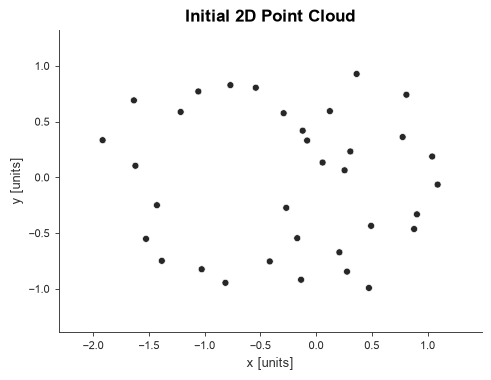

,source circle,x,y,direction weight
point,,,,
L00,large,0.2558,0.0633,0.8373
L01,large,0.3074,0.2322,0.8373
L02,large,-0.0802,0.3304,0.7350
L03,large,-0.2909,0.5755,0.4105
L04,large,-0.5409,0.8041,0.4184
L05,large,-0.7686,0.8273,0.2466
L06,large,-1.0563,0.7706,0.1460
L07,large,-1.2148,0.5867,0.5501
L08,large,-1.6344,0.6906,0.6283


In [3]:
def sample_two_overlapping_circles(seed):
    """Return an exactly reproducible, jittered sample from two circle boundaries."""
    coordinate_rng = np.random.default_rng(seed)
    circle_specs = (
        ('large', LARGE_CENTER, LARGE_RADIUS, N_LARGE, 0.0),
        ('small', SMALL_CENTER, SMALL_RADIUS, N_SMALL, SMALL_PHASE),
    )
    point_chunks = []
    source_labels = []
    for label, center, radius, count, phase in circle_specs:
        angles = phase + np.linspace(0, 2 * np.pi, count, endpoint=False)
        angles += coordinate_rng.normal(0.0, ANGULAR_JITTER_SD, count)
        radii = radius + coordinate_rng.normal(0.0, RADIAL_JITTER_SD, count)
        circle_points = np.column_stack((radii * np.cos(angles), radii * np.sin(angles)))
        circle_points += np.asarray(center)
        circle_points += coordinate_rng.normal(0.0, CARTESIAN_JITTER_SD, (count, 2))
        point_chunks.append(circle_points)
        source_labels.extend([label] * count)
    return np.vstack(point_chunks), tuple(source_labels)

points, circle_sources = sample_two_overlapping_circles(SEED)
large_ids = tuple(f'L{i:02d}' for i in range(N_LARGE))
small_ids = tuple(f'S{i:02d}' for i in range(N_SMALL))
point_ids = large_ids + small_ids
weight_rng = np.random.default_rng(SEED + 1)
weights = weight_rng.uniform(0.05, 0.95, N_POINTS)
equal_weight_pairs = ((large_ids[0], large_ids[1]), (small_ids[0], small_ids[1]))
weights[1] = weights[0]
weights[N_LARGE + 1] = weights[N_LARGE]

cloud = PointCloud(
    points, ids=point_ids, weights=weights,
    metadata={
        'coordinate_units': 'units',
        'generator': 'two overlapping circle boundaries with seeded jitter',
        'generator_seed': SEED,
        'circle_centers': (LARGE_CENTER, SMALL_CENTER),
        'circle_radii': (LARGE_RADIUS, SMALL_RADIUS),
    },
)
all_bonds = tuple(combinations(point_ids, 2))

fig, ax = plt.subplots(figsize=(4.8, 4.2), constrained_layout=True)
viz.plot_points(cloud, ax=ax, color_by_weights=False, title='Initial 2D Point Cloud')
point_artist = ax.collections[-1]
point_artist.set_facecolor(PALETTE['dark'])
point_artist.set_edgecolor('white')
point_artist.set_linewidth(0.45)
point_artist.set_sizes(np.full(N_POINTS, 25.0))
ax.set_xlabel('x [units]')
ax.set_ylabel('y [units]')
viz.clean_axis(ax, color=PALETTE['dark'])
viz.set_point_limits(ax, cloud, margin=ALPHA_RADIUS + 0.12)
publish_figure(fig, '01_initial_point_cloud')

point_table = pd.DataFrame({
    'point': point_ids,
    'source circle': circle_sources,
    'x': points[:, 0],
    'y': points[:, 1],
    'direction weight': weights,
}).set_index('point')
display(point_table.round(4))


## 2. Graph Representation

The graph contains the 34 points as vertices and adds one undirected edge for every pair whose distance is at most the cutoff $\varepsilon=0.55$. The dedicated graph plotting function receives only explicit vertices and edges. It does not fill triangles, and this figure intentionally omits the background proximity circles.

For this introductory workflow, graph homology and Laplacian analysis is restricted to $H_0$ and $L_0$. The $H_1$ and $L_1$ portions are left empty in both the stationary and persistent graph sections.

findfont: Failed to find font weight semibold, now using 700.


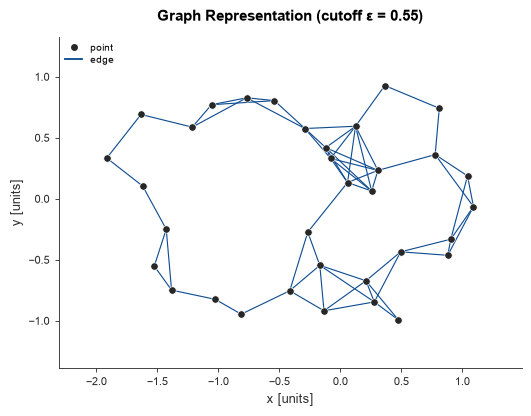

,count
graph item,
point (vertex),34
edge,63


In [4]:
graph_topology = simplicial.from_points(
    cloud, max_dimension=0, complex_type='graph', bonds=all_bonds,
    cutoff=EPSILON, max_scale=EPSILON,
)

fig, ax = plt.subplots(figsize=(5.2, 4.6), constrained_layout=True)
viz.plot_stationary_graph(
    graph_topology, scale=EPSILON, ax=ax,
    title=f'Graph Representation (cutoff ε = {EPSILON:.2f})',
    style=STATIONARY_STYLE, node_size=28, edge_width=0.82,
    limits_margin=ALPHA_RADIUS + 0.12,
)
graph_cells = {
    q: ax._topokit_view['cells_by_dimension'].get(q, ()) for q in (0, 1, 2)
}
publish_figure(fig, '02_graph_representation')

display(pd.DataFrame({
    'graph item': ['point (vertex)', 'edge'],
    'count': [len(graph_cells[0]), len(graph_cells[1])],
}).set_index('graph item'))


findfont: Failed to find font weight semibold, now using 700.


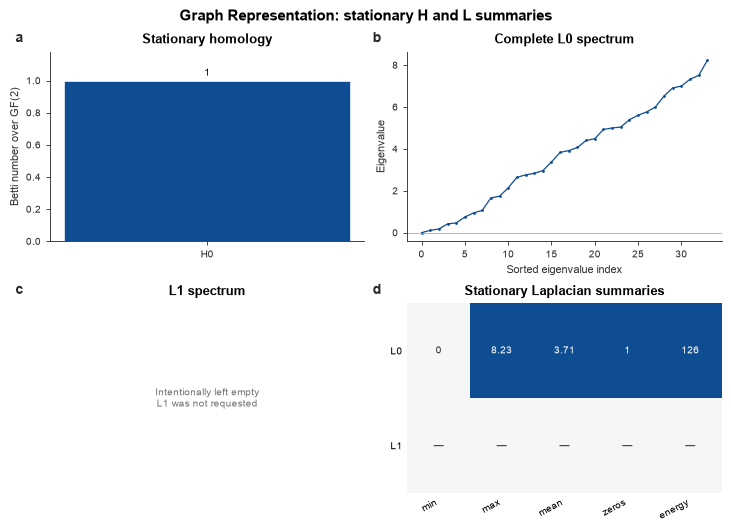

,minimum,maximum,mean,zero eigenvalues,spectral energy
Laplacian,,,,,
L0,0.0,8.230683,3.705882,1.0,126.0
L1,NaN,NaN,NaN,NaN,NaN


In [5]:
graph_result, graph_summary = publish_stationary_analysis(
    'Graph Representation', '02_graph', graph_topology, dimensions=(0,),
)


## 3. Simplicial Complex Representation

A simplicial complex combines compatible geometric pieces and includes every face of each piece:

- a **0-simplex** is one point,
- a **1-simplex** is an edge joining two points, and
- a **2-simplex** is a filled triangle supported by three points.

At the stationary cutoff, the 0- and 1-simplices use the same points and edges as the graph. Mutually connected triples are added as 2-simplices. Filling these triangles distinguishes the simplicial complex from its graph representation and changes $H_1$ and $L_1$.

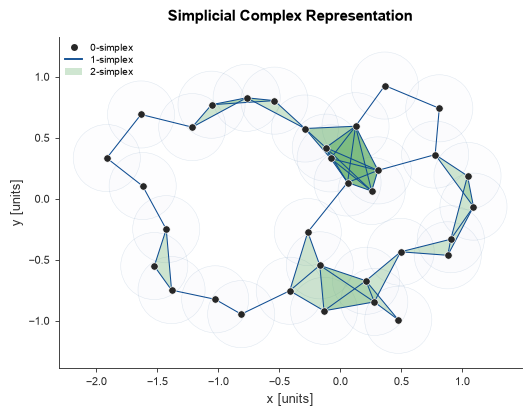

,count
simplex,
0-simplex (point),34
1-simplex (edge),63
2-simplex (triangle),39


In [6]:
simplicial_topology = simplicial.from_points(
    cloud, max_dimension=1, complex_type='flag', bonds=all_bonds,
    cutoff=EPSILON, max_scale=EPSILON,
)

fig, ax = plt.subplots(figsize=(5.2, 4.6), constrained_layout=True)
viz.plot_stationary_simplicial(
    simplicial_topology, scale=EPSILON, ax=ax,
    title='Simplicial Complex Representation', style=STATIONARY_STYLE,
    proximity_radius=ALPHA_RADIUS,
    circle_face_alpha=0.018, circle_edge_alpha=0.12,
    node_size=28, edge_width=0.75, face_alpha=0.34,
    limits_margin=ALPHA_RADIUS + 0.12,
)
simplicial_cells = {
    q: ax._topokit_view['cells_by_dimension'].get(q, ()) for q in (0, 1, 2)
}
publish_figure(fig, '03_simplicial_complex_representation')

display(pd.DataFrame({
    'simplex': ['0-simplex (point)', '1-simplex (edge)', '2-simplex (triangle)'],
    'count': [len(simplicial_cells[q]) for q in (0, 1, 2)],
}).set_index('simplex'))


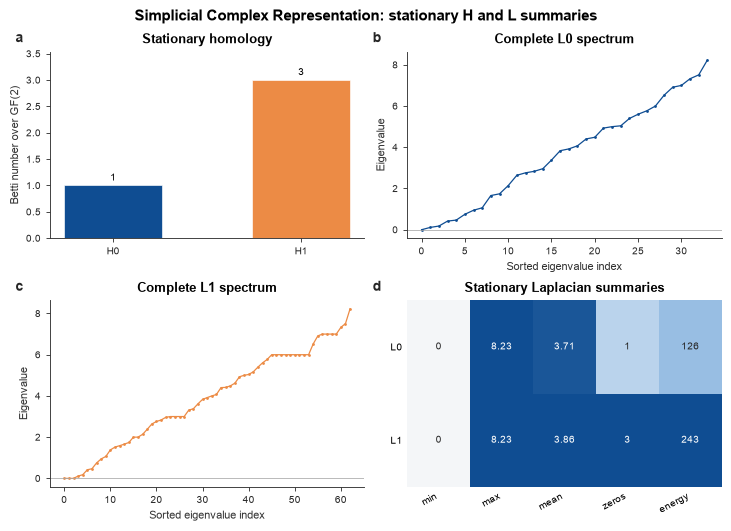

,minimum,maximum,mean,zero eigenvalues,spectral energy
Laplacian,,,,,
L0,0.0,8.230683,3.705882,1.0,126.0
L1,0.0,8.230683,3.857143,3.0,243.0


In [7]:
simplicial_result, simplicial_summary = publish_stationary_analysis(
    'Simplicial Complex Representation', '03_simplicial',
    simplicial_topology, dimensions=(0, 1),
)


## 4. Hyperdigraph Representation

The Hyperdigraph Representation adds order and direction to the same cutoff-based neighborhood:

- a **directed 0-hyperedge** is one point,
- a **directed 1-hyperedge** is an ordered pair shown by one arrow, and
- a **directed 2-hyperedge** is an ordered triple $v_0\to v_1\to v_2$ shown by two consecutive arrows.

These are directed hyperedges of TopoKit's sequence hyperdigraph, rather than unordered hyperedges from a hypergraph. An edge points from lower to higher point weight. Equal weights retain both directions, so the two deliberately tied pairs demonstrate reciprocal directed 1-hyperedges.

Several directed 2-hyperedges can reuse the same consecutive segment. Drawing that segment once for every parent hyperedge creates repeated parallel arrows. This example first collapses repeated segments within each displayed dimension. A directed 1-hyperedge is then drawn as a narrow blue foreground arrow. If the same oriented segment belongs to a displayed directed 2-hyperedge, a wider semi-transparent orange arrow is drawn underneath it on the **same arc**. The orange therefore signals higher-dimensional membership without creating another parallel lane. This is only a display rule; every directed hyperedge remains in the numerical object.

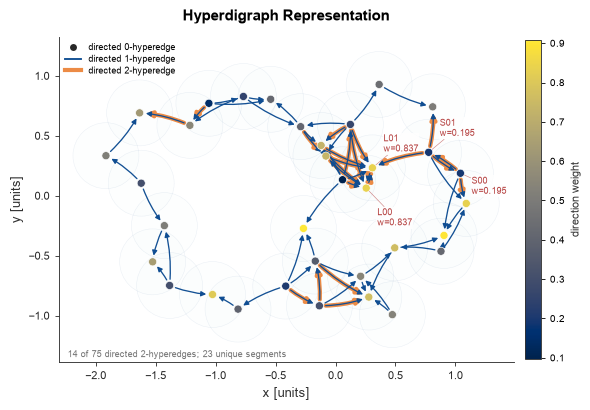

,full numerical count,displayed hyperedge paths,unique displayed arrow segments
directed hyperedge,,,
directed 0-hyperedge,34,34,0
directed 1-hyperedge,65,65,65
directed 2-hyperedge,75,14,23


,weight,L00 → L01,L01 → L00,S00 → S01,S01 → S00
equal-weight support,,,,,
L00 ↔ L01,0.837344,True,True,NaN,NaN
S00 ↔ S01,0.195048,NaN,NaN,True,True


In [8]:
hyperdigraph_topology = hyperdigraph.from_points(
    cloud, max_dimension=1, bonds=all_bonds,
    cutoff=EPSILON, max_scale=EPSILON,
)

tie_label_offsets = {
    large_ids[0]: (8, -14), large_ids[1]: (8, 10),
    small_ids[0]: (8, -2), small_ids[1]: (8, 10),
}
fig, ax = plt.subplots(figsize=(5.8, 4.9), constrained_layout=True)
viz.plot_stationary_hyperdigraph(
    hyperdigraph_topology, scale=EPSILON, ax=ax,
    title='Hyperdigraph Representation', style=STATIONARY_STYLE,
    proximity_radius=ALPHA_RADIUS,
    circle_face_alpha=0.012, circle_edge_alpha=0.075,
    display_counts={2: 14}, colorbar=True,
    annotate_weights=tuple(tie_label_offsets),
    annotation_offsets=tie_label_offsets,
    show_selection_summary=True, node_size=34, arrow_size=7.3,
    limits_margin=ALPHA_RADIUS + 0.12,
)
hyper_view = ax._topokit_view
hyper_cells = {
    q: hyper_view['source_cells_by_dimension'].get(q, ()) for q in (0, 1, 2)
}
selected_two_hyperedges = hyper_view['cells_by_dimension'].get(2, ())
display_one_segments = hyper_view['arrows_by_dimension'][1]
display_two_segments = hyper_view['arrows_by_dimension'][2]
publish_figure(fig, '04_hyperdigraph_representation')

weight_map = dict(zip(point_ids, weights))
directed_edges = set(hyper_cells[1])
reciprocal_table = pd.DataFrame([
    {
        'equal-weight support': f'{left} ↔ {right}',
        'weight': weight_map[left],
        f'{left} → {right}': (left, right) in directed_edges,
        f'{right} → {left}': (right, left) in directed_edges,
    }
    for left, right in equal_weight_pairs
]).set_index('equal-weight support')
display(pd.DataFrame({
    'directed hyperedge': [
        'directed 0-hyperedge', 'directed 1-hyperedge', 'directed 2-hyperedge',
    ],
    'full numerical count': [len(hyper_cells[q]) for q in (0, 1, 2)],
    'displayed hyperedge paths': [
        len(hyper_cells[0]), len(hyper_cells[1]), len(selected_two_hyperedges),
    ],
    'unique displayed arrow segments': [
        0, len(display_one_segments), len(display_two_segments),
    ],
}).set_index('directed hyperedge'))
display(reciprocal_table.round(6))


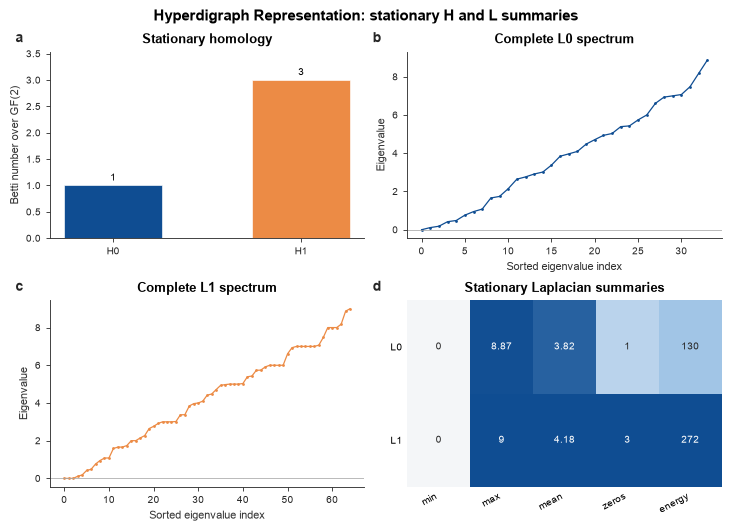

,minimum,maximum,mean,zero eigenvalues,spectral energy
Laplacian,,,,,
L0,0.0,8.871368,3.823529,1.0,130.0
L1,0.0,9.000000,4.184615,3.0,272.0


In [9]:
hyperdigraph_result, hyperdigraph_summary = publish_stationary_analysis(
    'Hyperdigraph Representation', '04_hyperdigraph',
    hyperdigraph_topology, dimensions=(0, 1),
)


## 5. Interaction Complex Representation

The Interaction Complex Representation follows TopoKit's two-factor interaction-complex protocol. Factor A is the 14-point sample from the smaller source circle. Factor B is the full 34-point cloud. The 14 shared stable point IDs define the overlap explicitly.

Each factor is first represented as a simplicial complex with points, edges, and triangles at the same stationary cutoff. TopoKit then forms its quotient-tensor interaction chain from pairs of factor simplices that share a mapped vertex. Orange rings identify the explicit overlap. The two panels display the factors because interaction-chain cells do not have a unique point-cloud embedding.

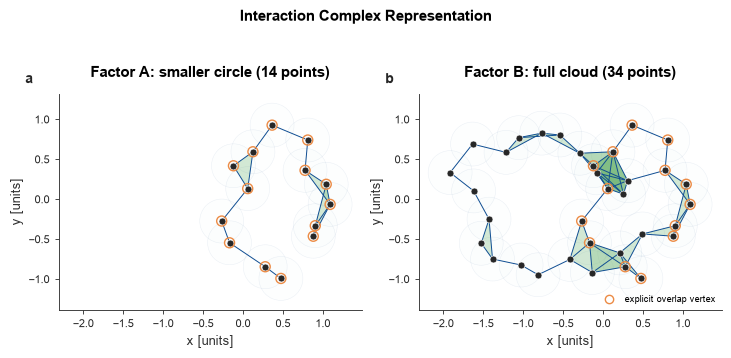

,factor A simplices,factor B simplices,interaction cells
degree,,,
0,14,34,14
1,17,63,90
2,4,39,194


In [10]:
subset_ids = small_ids
subset_cloud = cloud.subset(subset_ids)
subset_bonds = tuple(combinations(subset_ids, 2))
overlap_pairs = tuple((point_id, point_id) for point_id in subset_ids)

interaction_topology = interaction.from_points(
    subset_cloud, cloud, overlap_pairs=overlap_pairs,
    max_dimension=1, max_scale=EPSILON, factor_max_dimensions=(2, 2),
    factor_options=(
        {'complex_type': 'flag', 'bonds': subset_bonds, 'cutoff': EPSILON},
        {'complex_type': 'flag', 'bonds': all_bonds, 'cutoff': EPSILON},
    ),
    max_cells=2_000_000,
)
fig, axes = viz.plot_stationary_interaction(
    interaction_topology, scale=EPSILON,
    title='Interaction Complex Representation',
    factor_titles=(
        f'Factor A: smaller circle ({SUBSET_SIZE} points)',
        f'Factor B: full cloud ({N_POINTS} points)',
    ),
    style=STATIONARY_STYLE, proximity_radius=ALPHA_RADIUS,
    circle_face_alpha=0.012, circle_edge_alpha=0.075,
    node_size=25, edge_width=0.70, face_alpha=0.30,
    limits_margin=ALPHA_RADIUS + 0.12,
)
subset_cells = {
    q: axes[0]._topokit_view['cells_by_dimension'].get(q, ()) for q in (0, 1, 2)
}
full_cells = {
    q: axes[1]._topokit_view['cells_by_dimension'].get(q, ()) for q in (0, 1, 2)
}
publish_figure(fig, '05_interaction_complex_representation')

interaction_counts = interaction_topology.metadata[
    'construction_diagnostics'
]['interaction_cell_counts']
display(pd.DataFrame({
    'degree': ['0', '1', '2'],
    'factor A simplices': [len(subset_cells[q]) for q in (0, 1, 2)],
    'factor B simplices': [len(full_cells[q]) for q in (0, 1, 2)],
    'interaction cells': list(interaction_counts[:3]),
}).set_index('degree'))


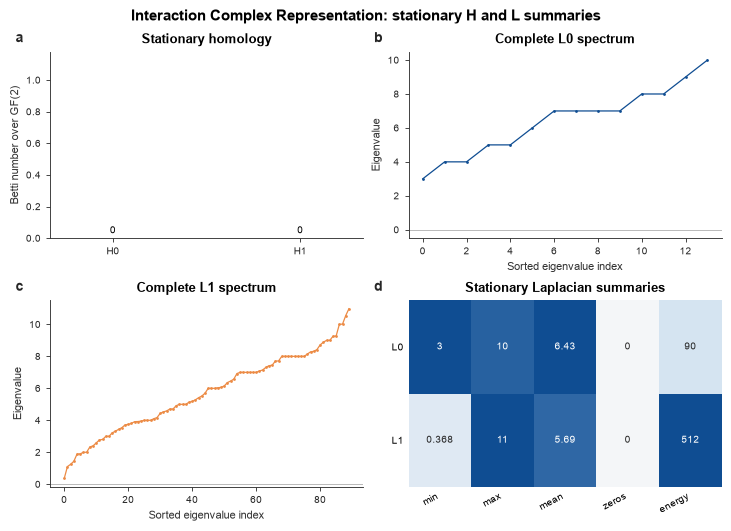

,minimum,maximum,mean,zero eigenvalues,spectral energy
Laplacian,,,,,
L0,3.000000,10.000000,6.428571,0.0,90.0
L1,0.367975,10.979952,5.688889,0.0,512.0


In [11]:
interaction_result, interaction_summary = publish_stationary_analysis(
    'Interaction Complex Representation', '05_interaction',
    interaction_topology, dimensions=(0, 1),
)


## 6. Persistent Analysis

The following sections increase a common displayed radius $\alpha$ from 0 to 0.80 and repeat the representation order used above. The persistent homology panels show intervals and the corresponding Betti curves. The Laplacian panels show how the minimum, maximum, all-eigenvalue mean, and spectral energy change across ordinary filtration snapshots.

TopoKit's default point-cloud construction is used for the persistent **Simplicial Complex** and both factors of the persistent **Interaction Complex**. Their native alpha-filtration coordinate is the squared radius, so the queried native scale is $\alpha^2$. Graph and Hyperdigraph edge births use Euclidean distance, so their displayed cutoff is $\varepsilon=2\alpha$. These conversions let every figure use the intuitive radius $\alpha$ without changing the package's native definitions.

The Laplacian curves below are a scale series of ordinary $L_q(\alpha)$ snapshots. TopoKit's genuine two-time persistent Laplacian $L_q(s,t)$ requires an explicit source-target pair and is a separate operation. The graph section intentionally records only $H_0$ and $L_0$; its $H_1$ and $L_1$ areas remain empty.

In [12]:
def distance_scale_from_alpha(alpha):
    return 2.0 * float(alpha)


def alpha_scale_from_alpha(alpha):
    return float(alpha) ** 2


def alpha_from_distance_scale(scale):
    return float(scale) / 2.0


def alpha_from_alpha_scale(scale):
    return math.sqrt(max(float(scale), 0.0))


def plot_alpha_barcodes(ax, bars, dimensions, native_to_alpha, alpha_max):
    intervals = sorted(
        (item for item in bars.intervals if item.dimension in dimensions),
        key=lambda item: (item.dimension, item.birth, item.death),
    )
    if not intervals:
        viz.empty_axis(ax, 'No retained persistence intervals',
                       color=PALETTE['gray'], title='Persistent homology intervals')
        return
    essential_end = alpha_max * 1.035
    labelled = set()
    for row, interval in enumerate(intervals):
        color = PALETTE['blue'] if interval.dimension == 0 else PALETTE['orange']
        birth = native_to_alpha(interval.birth)
        death = (
            essential_end if math.isinf(interval.death)
            else min(native_to_alpha(interval.death), alpha_max)
        )
        ax.plot(
            (birth, death), (row, row), color=color, linewidth=1.1,
            label=f'H{interval.dimension}' if interval.dimension not in labelled else None,
        )
        labelled.add(interval.dimension)
        # H0 intervals truly include alpha=0, so their line starts directly at 0.
        if interval.at_initial_stage and interval.dimension != 0:
            ax.plot(
                birth, row, marker='o', markerfacecolor='white',
                markeredgecolor=color, markersize=2.8,
            )
        if math.isinf(interval.death):
            ax.plot(death, row, marker='>', color=color, markersize=4)
    ax.set_xlim(-0.015 * alpha_max, essential_end + 0.015 * alpha_max)
    viz.clean_axis(ax, color=PALETTE['dark'])
    ax.set_xlabel('Radius α')
    ax.set_ylabel('Interval index')
    ax.set_title('Persistent homology intervals')
    ax.legend(loc='upper right')


def plot_laplacian_curves(ax, table, dimension):
    prefix = f'L{dimension}_'
    if table[f'{prefix}minimum'].isna().all():
        viz.empty_axis(
            ax, 'Intentionally left empty\nGraph scope: H0 and L0',
            color=PALETTE['gray'], title=f'L{dimension} along the filtration',
        )
        return
    alpha = table['alpha'].to_numpy(dtype=float)
    styles = (
        ('minimum', 'minimum', PALETTE['dark'], ':'),
        ('maximum', 'maximum', PALETTE['blue'], '-'),
        ('mean', 'mean', PALETTE['teal'], '--'),
    )
    lines = []
    for column, label, color, linestyle in styles:
        line, = ax.plot(
            alpha, table[f'{prefix}{column}'],
            color=color, linestyle=linestyle, linewidth=1.15,
            marker='o', markersize=1.8, markeredgewidth=0,
            markevery=2, label=label,
        )
        lines.append(line)
    energy_axis = ax.twinx()
    energy_line, = energy_axis.plot(
        alpha, table[f'{prefix}energy'], color=PALETTE['orange'],
        linewidth=1.2, label='energy',
    )
    energy_axis.spines['right'].set_visible(True)
    energy_axis.set_ylabel('Energy', color=PALETTE['orange'])
    energy_axis.tick_params(axis='y', colors=PALETTE['orange'])
    energy_axis.grid(False)
    viz.clean_axis(ax, color=PALETTE['dark'])
    ax.set_xlabel('Radius α')
    ax.set_ylabel('Eigenvalue statistic')
    ax.set_title(f'L{dimension} statistics along the filtration')
    ax.legend(lines + [energy_line], [line.get_label() for line in lines] + ['energy'],
              loc='upper left', ncol=2, fontsize=7)


def analyze_persistence(name, slug, topology, *, dimensions,
                        scale_from_alpha, alpha_from_scale):
    """Record persistent homology and ordinary Laplacian snapshot curves."""
    dimensions = tuple(dimensions)
    bars = core.persistence(topology, max_dimension=max(dimensions))
    rows = []
    for alpha in PERSISTENT_ALPHA_VALUES:
        native_scale = scale_from_alpha(alpha)
        betti = bars.betti_at(native_scale)
        row = {
            'alpha': float(alpha),
            'native scale': native_scale,
            'beta_0': int(betti[0]),
            'beta_1': int(betti[1]) if 1 in dimensions else np.nan,
        }
        for q in (0, 1):
            if q in dimensions:
                spectrum = core.laplacian(topology, dimension=q, scale=native_scale)
                values = spectrum_summary(spectrum)
                row.update({
                    f'L{q}_minimum': values['min'],
                    f'L{q}_maximum': values['max'],
                    f'L{q}_mean': values['mean'],
                    f'L{q}_zero_count': values['zero_count'],
                    f'L{q}_energy': values['energy'],
                })
            else:
                row.update({
                    f'L{q}_{key}': np.nan
                    for key in ('minimum', 'maximum', 'mean', 'zero_count', 'energy')
                })
        rows.append(row)
    table = pd.DataFrame(rows)
    table.to_csv(OUTPUT_DIR / f'{slug}_persistent_summary.csv', index=False, na_rep='')

    fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.3), constrained_layout=True)
    plot_alpha_barcodes(
        axes[0, 0], bars, dimensions, alpha_from_scale, PERSISTENT_ALPHA_MAX,
    )
    for q in dimensions:
        axes[0, 1].step(
            table['alpha'], table[f'beta_{q}'], where='post',
            color=PALETTE['blue'] if q == 0 else PALETTE['orange'],
            linewidth=1.3, label=f'H{q}',
        )
    viz.clean_axis(axes[0, 1], color=PALETTE['dark'])
    axes[0, 1].set_xlabel('Radius α')
    axes[0, 1].set_ylabel('Betti number over GF(2)')
    axes[0, 1].set_title('Betti curves')
    axes[0, 1].legend()
    plot_laplacian_curves(axes[1, 0], table, 0)
    plot_laplacian_curves(axes[1, 1], table, 1)
    for label, ax in zip('abcd', axes.flat):
        viz.add_panel_label(ax, label, color=PALETTE['dark'])
    fig.suptitle(f'{name}: persistent homology and Laplacian curves')
    publish_figure(fig, f'{slug}_persistent_analysis')

    selected_rows = np.unique(np.linspace(0, len(table) - 1, 7, dtype=int))
    display(table.iloc[selected_rows].round(5))
    return {'persistence': bars, 'table': table}


### 6.1 Graph Persistent Analysis

Each edge enters when its endpoint distance reaches the current cutoff $\varepsilon=2\alpha$. The barcode and Betti curve record connected components through $H_0$. The $L_0$ curves summarize changing graph connectivity. $H_1$ and $L_1$ are intentionally left empty for this graph demonstration.

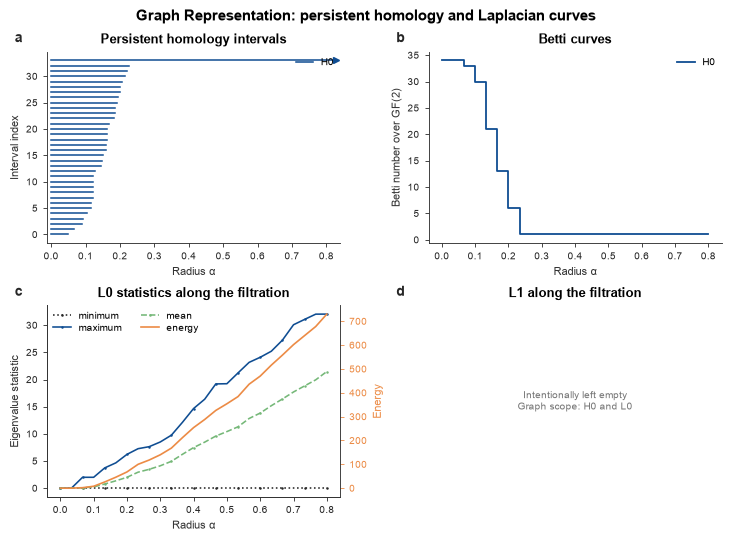

,alpha,native scale,beta_0,beta_1,L0_minimum,L0_maximum,L0_mean,L0_zero_count,L0_energy,L1_minimum,L1_maximum,L1_mean,L1_zero_count,L1_energy
0,0.00000,0.00000,34,NaN,0.0,0.00000,0.00000,34.0,0.0,NaN,NaN,NaN,NaN,NaN
4,0.13333,0.26667,21,NaN,0.0,3.73205,0.76471,21.0,26.0,NaN,NaN,NaN,NaN,NaN
8,0.26667,0.53333,1,NaN,0.0,7.63581,3.47059,1.0,118.0,NaN,NaN,NaN,NaN,NaN
12,0.40000,0.80000,1,NaN,0.0,14.66009,7.47059,1.0,254.0,NaN,NaN,NaN,NaN,NaN
16,0.53333,1.06667,1,NaN,0.0,21.20838,11.29412,1.0,384.0,NaN,NaN,NaN,NaN,NaN
20,0.66667,1.33333,1,NaN,0.0,27.24218,16.41176,1.0,558.0,NaN,NaN,NaN,NaN,NaN
24,0.80000,1.60000,1,NaN,0.0,32.03660,21.47059,1.0,730.0,NaN,NaN,NaN,NaN,NaN


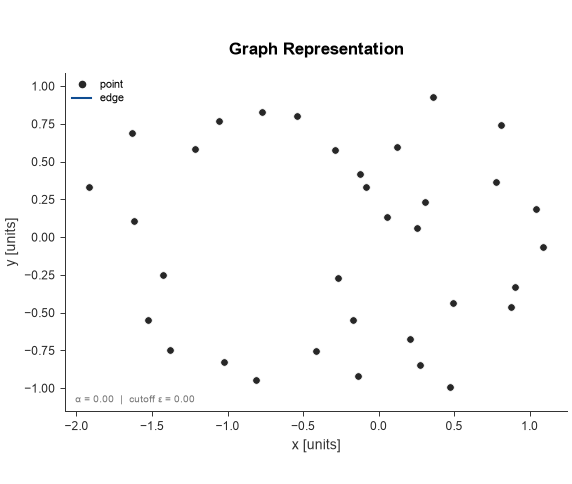

In [13]:
persistent_graph_max_scale = distance_scale_from_alpha(PERSISTENT_ALPHA_MAX)
persistent_graph_topology = simplicial.from_points(
    cloud, max_dimension=0, complex_type='graph', bonds=all_bonds,
    cutoff=persistent_graph_max_scale, max_scale=persistent_graph_max_scale,
)

graph_persistent_result = analyze_persistence(
    'Graph Representation', '06_graph', persistent_graph_topology,
    dimensions=(0,), scale_from_alpha=distance_scale_from_alpha,
    alpha_from_scale=alpha_from_distance_scale,
)

graph_gif_figure, graph_gif_axis = plt.subplots(
    figsize=(5.2, 4.4), constrained_layout=True,
)

def draw_graph_frame(alpha):
    graph_gif_axis.clear()
    viz.plot_stationary_graph(
        persistent_graph_topology, scale=distance_scale_from_alpha(alpha),
        ax=graph_gif_axis, title='Graph Representation',
        style=STATIONARY_STYLE, node_size=24, edge_width=0.68,
        limits_margin=0.16,
    )
    add_frame_annotation(
        graph_gif_axis, f'α = {alpha:.2f}  |  cutoff ε = {2*alpha:.2f}',
    )

graph_gif_path = publish_gif(
    graph_gif_figure, draw_graph_frame, GIF_ALPHA_VALUES,
    '06_graph_connectivity',
)


### 6.2 Simplicial Complex Persistent Analysis

The default alpha construction adds 0-simplices, 1-simplices, and 2-simplices as $\alpha$ grows. Persistent $H_0$ records component merging, while persistent $H_1$ records loop formation and filling. The $L_0$ and $L_1$ curves use the corresponding simplicial chain spaces at each radius.

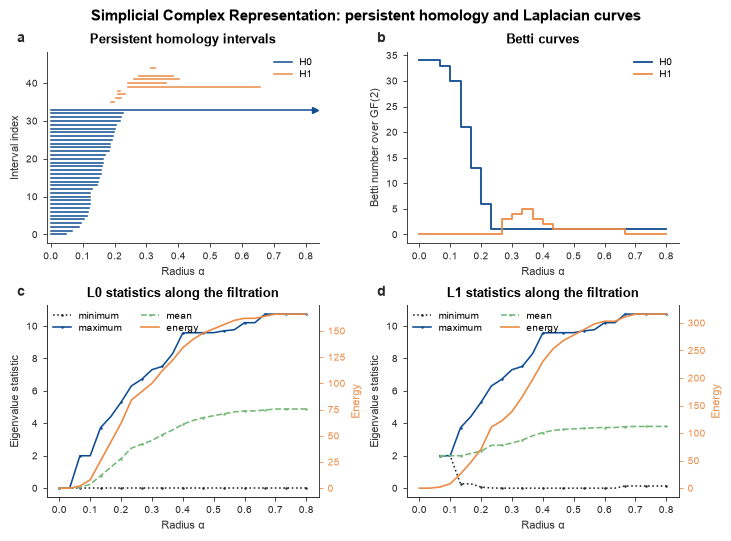

,alpha,native scale,beta_0,beta_1,L0_minimum,L0_maximum,L0_mean,L0_zero_count,L0_energy,L1_minimum,L1_maximum,L1_mean,L1_zero_count,L1_energy
0,0.00000,0.00000,34,0,0.0,0.00000,0.00000,34.0,0.0,NaN,NaN,NaN,0.0,0.0
4,0.13333,0.01778,21,0,0.0,3.73205,0.76471,21.0,26.0,0.26795,3.73205,2.00000,0.0,26.0
8,0.26667,0.07111,1,3,0.0,6.71551,2.70588,1.0,92.0,0.00000,6.71551,2.65217,3.0,122.0
12,0.40000,0.16000,1,2,0.0,9.57544,3.94118,1.0,134.0,0.00000,9.57544,3.43284,2.0,230.0
16,0.53333,0.28444,1,1,0.0,9.70499,4.58824,1.0,156.0,0.00000,9.70499,3.69231,1.0,288.0
20,0.66667,0.44444,1,0,0.0,10.73637,4.82353,1.0,164.0,0.13450,10.73637,3.79268,0.0,311.0
24,0.80000,0.64000,1,0,0.0,10.73666,4.88235,1.0,166.0,0.13383,10.73666,3.80723,0.0,316.0


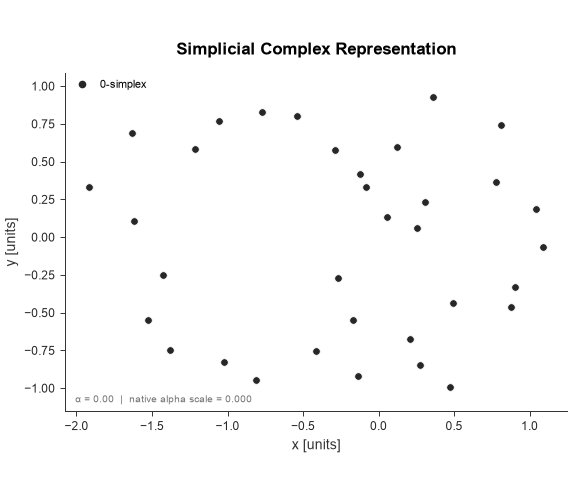

In [14]:
persistent_simplicial_max_scale = alpha_scale_from_alpha(PERSISTENT_ALPHA_MAX)
# Omitting complex_type invokes TopoKit's default alpha construction.
persistent_simplicial_topology = simplicial.from_points(
    cloud, max_dimension=1, max_scale=persistent_simplicial_max_scale,
)

simplicial_persistent_result = analyze_persistence(
    'Simplicial Complex Representation', '07_simplicial',
    persistent_simplicial_topology, dimensions=(0, 1),
    scale_from_alpha=alpha_scale_from_alpha,
    alpha_from_scale=alpha_from_alpha_scale,
)

simplicial_gif_figure, simplicial_gif_axis = plt.subplots(
    figsize=(5.2, 4.4), constrained_layout=True,
)

def draw_simplicial_frame(alpha):
    simplicial_gif_axis.clear()
    viz.plot_stationary_simplicial(
        persistent_simplicial_topology, scale=alpha_scale_from_alpha(alpha),
        ax=simplicial_gif_axis, title='Simplicial Complex Representation',
        style=STATIONARY_STYLE, proximity_radius=alpha,
        circle_face_alpha=0.012, circle_edge_alpha=0.13,
        node_size=24, edge_width=0.65, face_alpha=0.30,
        limits_margin=0.16,
    )
    add_frame_annotation(
        simplicial_gif_axis,
        f'α = {alpha:.2f}  |  native alpha scale = {alpha**2:.3f}',
    )

simplicial_gif_path = publish_gif(
    simplicial_gif_figure, draw_simplicial_frame, GIF_ALPHA_VALUES,
    '07_simplicial_complex_filtration',
)


### 6.3 Hyperdigraph Persistent Analysis

The persistent Hyperdigraph uses the package's default Delaunay-supported neighborhood. A directed 1-hyperedge enters at its edge distance, and a directed 2-hyperedge enters when the longest consecutive edge in its ordered sequence has appeared. The GIF shows every directed 0- and 1-hyperedge plus a fixed readable selection of directed 2-hyperedges. Reused consecutive segments are collapsed; a directed-2 segment appears as a wider semi-transparent orange on the same arc as the narrow blue directed-1 arrow. The growing circles have radius $\alpha$, so overlap occurs at the displayed cutoff $\varepsilon=2\alpha$.

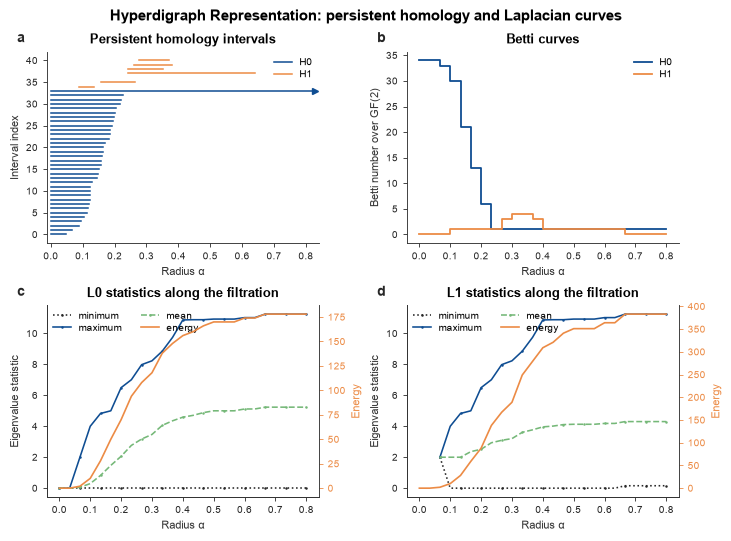

,alpha,native scale,beta_0,beta_1,L0_minimum,L0_maximum,L0_mean,L0_zero_count,L0_energy,L1_minimum,L1_maximum,L1_mean,L1_zero_count,L1_energy
0,0.00000,0.00000,34,0,0.0,0.00000,0.00000,34.0,0.0,NaN,NaN,NaN,0.0,0.0
4,0.13333,0.26667,21,1,0.0,4.82801,0.82353,21.0,28.0,0.00000,4.82801,2.00000,1.0,28.0
8,0.26667,0.53333,1,3,0.0,7.98289,3.17647,1.0,108.0,0.00000,7.98289,3.09259,3.0,167.0
12,0.40000,0.80000,1,1,0.0,10.87312,4.58824,1.0,156.0,0.00000,10.87312,3.96154,1.0,309.0
16,0.53333,1.06667,1,1,0.0,10.92849,5.00000,1.0,170.0,0.00000,10.92849,4.12941,1.0,351.0
20,0.66667,1.33333,1,0,0.0,11.24967,5.23529,1.0,178.0,0.15634,11.24967,4.30337,0.0,383.0
24,0.80000,1.60000,1,0,0.0,11.24967,5.23529,1.0,178.0,0.15634,11.24967,4.30337,0.0,383.0


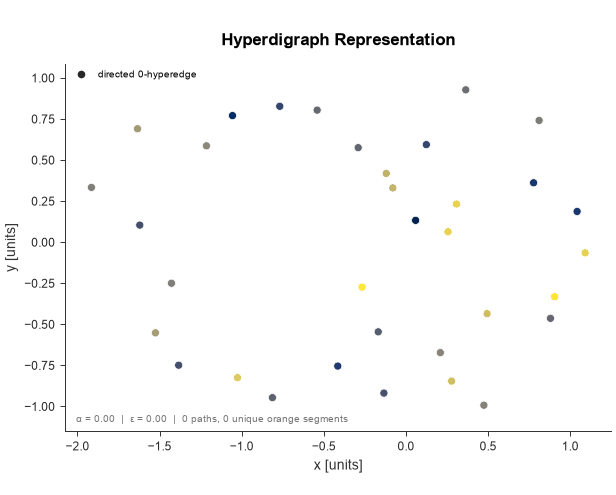

In [15]:
persistent_hyperdigraph_max_scale = distance_scale_from_alpha(PERSISTENT_ALPHA_MAX)
# Omitting bonds invokes TopoKit's default Delaunay-supported construction.
persistent_hyperdigraph_topology = hyperdigraph.from_points(
    cloud, max_dimension=1, max_scale=persistent_hyperdigraph_max_scale,
)

hyperdigraph_persistent_result = analyze_persistence(
    'Hyperdigraph Representation', '08_hyperdigraph',
    persistent_hyperdigraph_topology, dimensions=(0, 1),
    scale_from_alpha=distance_scale_from_alpha,
    alpha_from_scale=alpha_from_distance_scale,
)

final_hyper_snapshot = persistent_hyperdigraph_topology.native.snapshot(
    persistent_hyperdigraph_max_scale,
)
final_two_hyperedges = final_hyper_snapshot.directed_hyperedges(2)
gif_two_count = min(14, len(final_two_hyperedges))
gif_two_indices = (
    np.linspace(0, len(final_two_hyperedges) - 1, gif_two_count, dtype=int)
    if gif_two_count else []
)
gif_two_hyperedges = tuple(final_two_hyperedges[index] for index in gif_two_indices)

hyperdigraph_gif_figure, hyperdigraph_gif_axis = plt.subplots(
    figsize=(5.6, 4.5), constrained_layout=True,
)

def draw_hyperdigraph_frame(alpha):
    hyperdigraph_gif_axis.clear()
    snapshot = persistent_hyperdigraph_topology.native.snapshot(
        distance_scale_from_alpha(alpha),
    )
    frame_two_set = set(snapshot.directed_hyperedges(2))
    frame_two = tuple(edge for edge in gif_two_hyperedges if edge in frame_two_set)
    viz.plot_stationary_hyperdigraph(
        persistent_hyperdigraph_topology,
        scale=distance_scale_from_alpha(alpha), ax=hyperdigraph_gif_axis,
        title='Hyperdigraph Representation', style=STATIONARY_STYLE,
        proximity_radius=alpha,
        circle_face_alpha=0.008, circle_edge_alpha=0.10,
        display_hyperedges={2: frame_two}, colorbar=False,
        node_size=28, arrow_size=6.5, limits_margin=0.16,
    )
    frame_view = hyperdigraph_gif_axis._topokit_view
    frame_two_segments = frame_view['arrows_by_dimension'][2]
    add_frame_annotation(
        hyperdigraph_gif_axis,
        f'α = {alpha:.2f}  |  ε = {2*alpha:.2f}  |  '
        f'{len(frame_two)} paths, {len(frame_two_segments)} unique orange segments',
    )

hyperdigraph_gif_path = publish_gif(
    hyperdigraph_gif_figure, draw_hyperdigraph_frame, GIF_ALPHA_VALUES,
    '08_hyperdigraph_filtration',
)


### 6.4 Interaction Complex Persistent Analysis

Both factors use the default alpha construction and the interaction filtration uses the maximum of their simplex birth scales. Persistent $H_0/H_1$ and the $L_0/L_1$ curves are computed from the interaction chain. The GIF displays the two evolving factor complexes and their explicit 14-vertex overlap.

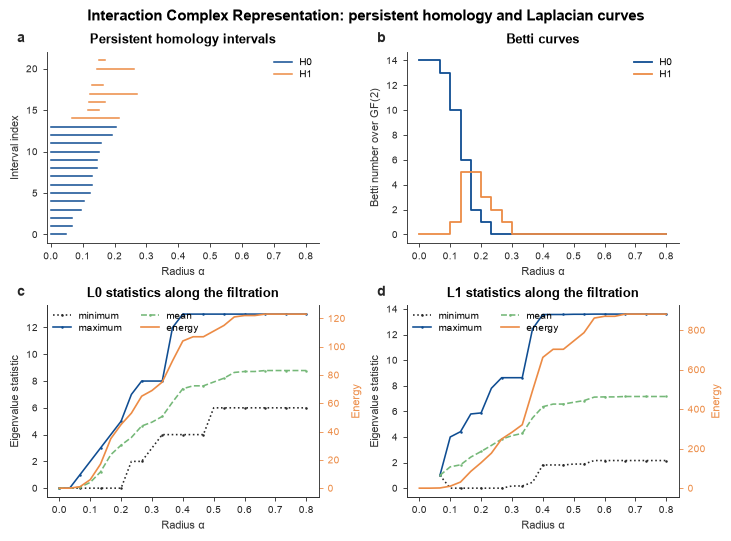

,alpha,native scale,beta_0,beta_1,L0_minimum,L0_maximum,L0_mean,L0_zero_count,L0_energy,L1_minimum,L1_maximum,L1_mean,L1_zero_count,L1_energy
0,0.00000,0.00000,14,0,0.0,0.0,0.00000,14.0,0.0,NaN,NaN,NaN,0.0,0.0
4,0.13333,0.01778,6,5,0.0,3.0,1.21429,6.0,17.0,0.00000,4.41421,1.82353,5.0,31.0
8,0.26667,0.07111,0,1,2.0,8.0,4.64286,0.0,65.0,0.00000,8.63129,3.83077,1.0,249.0
12,0.40000,0.16000,0,0,4.0,13.0,7.42857,0.0,104.0,1.81175,13.56576,6.36538,0.0,662.0
16,0.53333,0.28444,0,0,6.0,13.0,8.21429,0.0,115.0,1.88496,13.58810,6.84348,0.0,787.0
20,0.66667,0.44444,0,0,6.0,13.0,8.78571,0.0,123.0,2.15915,13.60056,7.16260,0.0,881.0
24,0.80000,0.64000,0,0,6.0,13.0,8.78571,0.0,123.0,2.15915,13.60056,7.16260,0.0,881.0


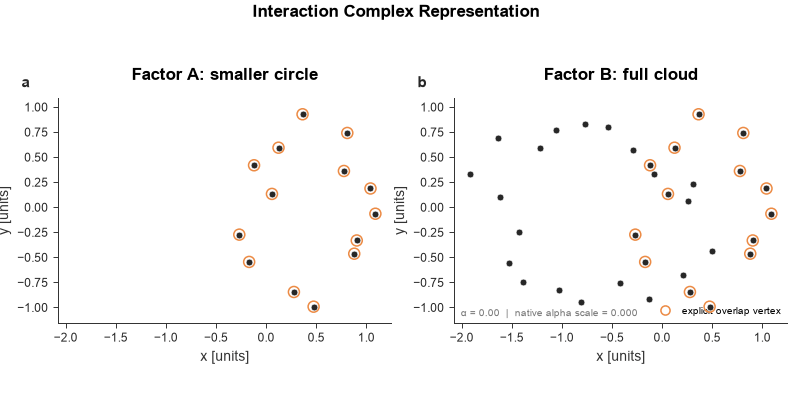

In [16]:
persistent_interaction_max_scale = alpha_scale_from_alpha(PERSISTENT_ALPHA_MAX)
persistent_interaction_topology = interaction.from_points(
    subset_cloud, cloud, overlap_pairs=overlap_pairs,
    max_dimension=1, max_scale=persistent_interaction_max_scale,
    factor_max_dimensions=(2, 2), max_cells=2_000_000,
)

interaction_persistent_result = analyze_persistence(
    'Interaction Complex Representation', '09_interaction',
    persistent_interaction_topology, dimensions=(0, 1),
    scale_from_alpha=alpha_scale_from_alpha,
    alpha_from_scale=alpha_from_alpha_scale,
)

interaction_gif_figure, interaction_gif_axes = plt.subplots(
    1, 2, figsize=(7.2, 3.6), constrained_layout=True,
)

def draw_interaction_frame(alpha):
    for axis in interaction_gif_axes:
        axis.clear()
    scale = alpha_scale_from_alpha(alpha)
    viz.plot_stationary_interaction(
        persistent_interaction_topology, scale=scale, axes=interaction_gif_axes,
        title='Interaction Complex Representation',
        factor_titles=('Factor A: smaller circle', 'Factor B: full cloud'),
        style=STATIONARY_STYLE, proximity_radius=alpha,
        circle_face_alpha=0.008, circle_edge_alpha=0.10,
        node_size=20, edge_width=0.58, face_alpha=0.28,
        limits_margin=0.16,
    )
    add_frame_annotation(
        interaction_gif_axes[1],
        f'α = {alpha:.2f}  |  native alpha scale = {scale:.3f}',
    )

interaction_gif_path = publish_gif(
    interaction_gif_figure, draw_interaction_frame, GIF_ALPHA_VALUES,
    '09_interaction_complex_filtration',
)


## Reproducibility and numerical checks

These checks verify the fixed-seed point cloud, geometric overlap, explicit graph scope, simplex and directed-hyperedge construction, reciprocal tied directions, complete positive-semidefinite spectra, persistent table layout, and GIF creation.

In [17]:
regenerated_points, regenerated_sources = sample_two_overlapping_circles(SEED)
center_distance = np.linalg.norm(np.asarray(LARGE_CENTER) - np.asarray(SMALL_CENTER))

assert np.array_equal(points, regenerated_points)
assert circle_sources == regenerated_sources
assert abs(LARGE_RADIUS - SMALL_RADIUS) < center_distance < LARGE_RADIUS + SMALL_RADIUS
assert len(graph_cells[0]) == N_POINTS and len(graph_cells[2]) == 0
assert len(simplicial_cells[0]) == N_POINTS and len(simplicial_cells[2]) > 0
assert tuple(graph_result.spectra) == (0,)
assert graph_summary.loc['L1'].isna().all()
assert all(
    (left, right) in directed_edges and (right, left) in directed_edges
    for left, right in equal_weight_pairs
)
assert len(display_one_segments) == len(set(display_one_segments))
assert len(display_two_segments) == len(set(display_two_segments))
assert hyper_view['max_connections_per_support'][1] <= 2
assert hyper_view['max_connections_per_support'][2] <= 2
assert hyper_view['max_connections_per_support']['total'] <= 4
assert hyper_view['proximity_circle_count'] == N_POINTS

stationary_results = (
    graph_result, simplicial_result, hyperdigraph_result, interaction_result,
)
for result in stationary_results:
    for spectrum in result.spectra.values():
        assert spectrum.complete
        assert np.all(spectrum.eigenvalues >= -TOL)

assert persistent_simplicial_topology.metadata.get('complex_type') == 'alpha'
assert all(
    options['complex_type'] == 'alpha'
    for options in persistent_interaction_topology.metadata['factor_options']
)
assert graph_persistent_result['table']['beta_1'].isna().all()
assert graph_persistent_result['table'].filter(regex=r'^L1_').isna().all().all()

persistent_results = (
    graph_persistent_result,
    simplicial_persistent_result,
    hyperdigraph_persistent_result,
    interaction_persistent_result,
)
for result in persistent_results:
    alpha_values = result['table']['alpha'].to_numpy(dtype=float)
    assert np.all(np.diff(alpha_values) > 0)
    for column in result['table'].filter(regex=r'_energy$'):
        values = result['table'][column].dropna().to_numpy(dtype=float)
        assert np.all(values >= -TOL)

gif_paths = (
    graph_gif_path, simplicial_gif_path,
    hyperdigraph_gif_path, interaction_gif_path,
)
assert all(path.is_file() and path.stat().st_size > 0 for path in gif_paths)

print('All fixed-seed, stationary, persistent, spectral, and GIF checks passed.')
print(f'Outputs saved under {OUTPUT_DIR.relative_to(PROJECT_ROOT)}')


All fixed-seed, stationary, persistent, spectral, and GIF checks passed.
Outputs saved under examples/output/point_cloud_topology_workflow


## Rerunning the notebook

From the TopoKit project root:

```bash
conda env create -f environment.yml
conda activate topokit
python -m ipykernel install --user --name topokit --display-name "Python (topokit)"
jupyter lab examples/point_cloud_topology_workflow.ipynb
```

`SEED` fixes every random displacement and weight. The stationary representation is controlled by `EPSILON`; its displayed proximity-ball radius remains `EPSILON / 2`. Persistent resolution and extent are controlled by `PERSISTENT_ALPHA_VALUES`, `GIF_ALPHA_VALUES`, and `PERSISTENT_ALPHA_MAX`. The persistent Simplicial Complex and Interaction Complex use TopoKit's default alpha construction, while the Graph and Hyperdigraph use their documented distance-filtration conventions.